In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It ischrome://newtab/ defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv


In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [3]:
DATA_PATH = "/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")
print("Rows and Columns:", df.shape)
display(df.head())

Dataset Loaded Successfully
Rows and Columns: (10000, 17)


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [4]:
print("\nDataset Information:")
display(df.info())

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDescriptive Statistics:")
display(df.describe())

# Create output folders
os.makedirs("/kaggle/working/figures", exist_ok=True)
os.makedirs("/kaggle/working/tables", exist_ok=True)

df.describe().to_csv("/kaggle/working/tables/descriptive_statistics.csv")
df.isnull().sum().to_csv("/kaggle/working/tables/missing_values.csv")



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Campaign_ID                        10000 non-null  object 
 1   Product_ID                         10000 non-null  object 
 2   Budget                             10000 non-null  float64
 3   Clicks                             10000 non-null  int64  
 4   Conversions                        10000 non-null  int64  
 5   Revenue_Generated                  10000 non-null  float64
 6   ROI                                10000 non-null  float64
 7   Customer_ID                        10000 non-null  object 
 8   Subscription_Tier                  10000 non-null  object 
 9   Subscription_Length                10000 non-null  int64  
 10  Flash_Sale_ID                      10000 non-null  object 
 11  Discount_Level                   

None


Missing Values:


Campaign_ID                          0
Product_ID                           0
Budget                               0
Clicks                               0
Conversions                          0
Revenue_Generated                    0
ROI                                  0
Customer_ID                          0
Subscription_Tier                    0
Subscription_Length                  0
Flash_Sale_ID                        0
Discount_Level                       0
Units_Sold                           0
Bundle_ID                            0
Bundle_Price                         0
Customer_Satisfaction_Post_Refund    0
Common_Keywords                      0
dtype: int64


Descriptive Statistics:


,Budget,Clicks,Conversions,Revenue_Generated,ROI,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,25263.607524,2481.903600,498.978700,50038.627579,2.756365,18.016500,39.421000,100.689600,275.198346,2.500900
std,14350.085927,1435.973623,289.479495,28545.702337,1.296901,10.149666,17.212925,57.074015,129.218710,1.113249
min,500.440000,10.000000,1.000000,1002.080000,0.500000,1.000000,10.000000,1.000000,50.010000,1.000000
25%,12789.190000,1225.750000,247.000000,25264.255000,1.630000,9.000000,24.000000,52.000000,165.717500,2.000000
50%,25030.170000,2451.000000,499.000000,49513.815000,2.750000,18.000000,39.000000,101.000000,272.555000,2.000000
75%,37921.725000,3723.000000,751.000000,74507.157500,3.890000,27.000000,54.000000,150.000000,387.322500,3.000000
max,49999.630000,4999.000000,999.000000,99999.470000,5.000000,35.000000,69.000000,199.000000,499.970000,4.000000


In [5]:
target = "ROI"

print("\nTarget Variable:", target)
print(df[target].describe())


Target Variable: ROI
count    10000.000000
mean         2.756365
std          1.296901
min          0.500000
25%          1.630000
50%          2.750000
75%          3.890000
max          5.000000
Name: ROI, dtype: float64


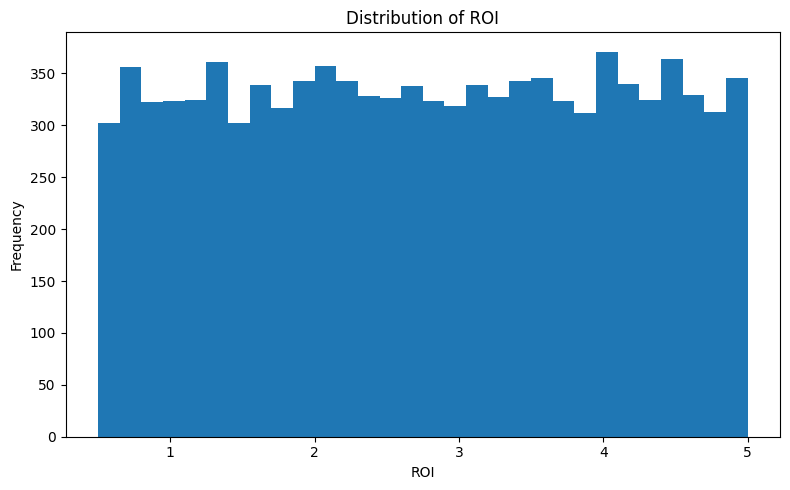

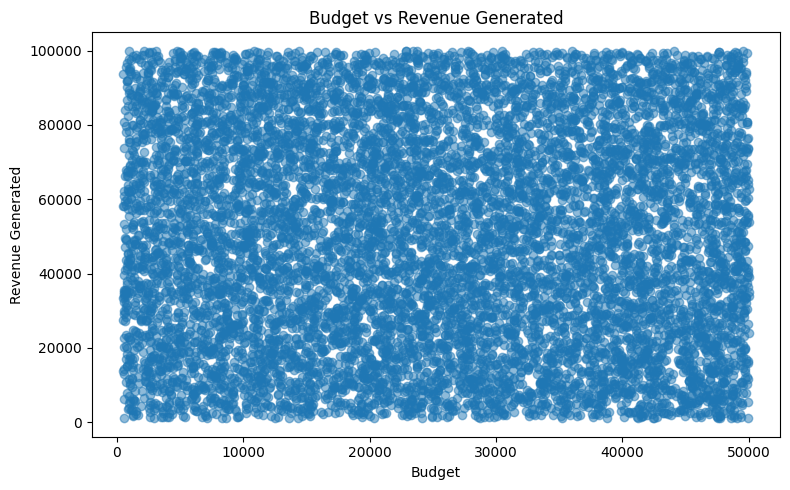

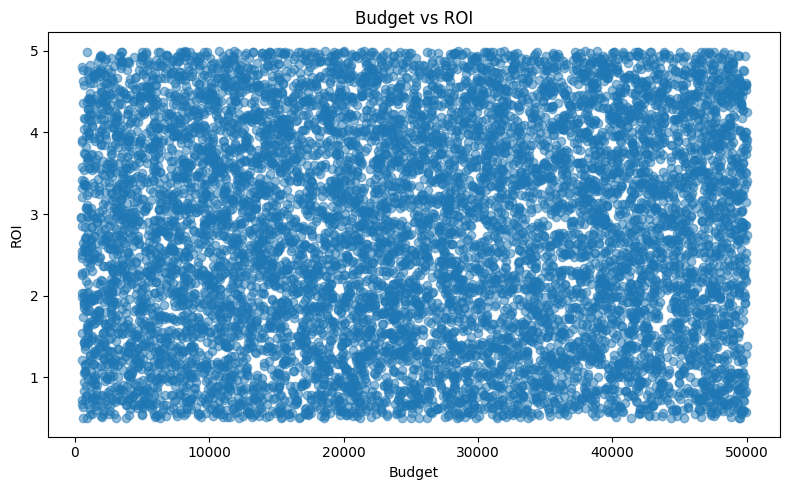

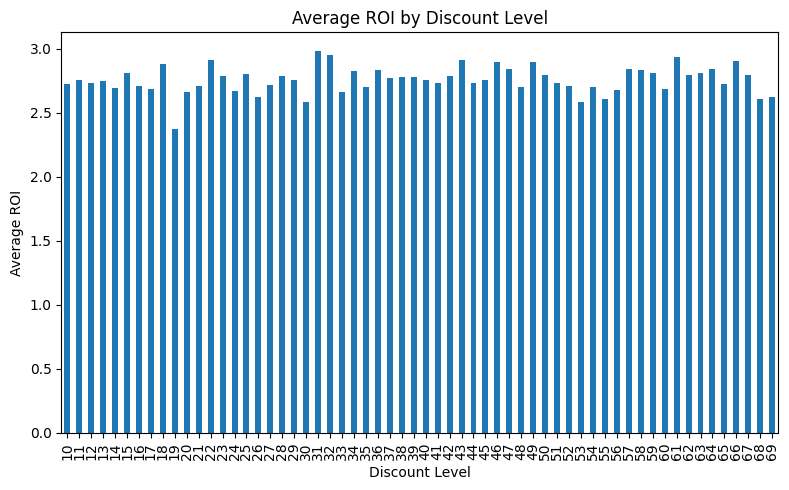

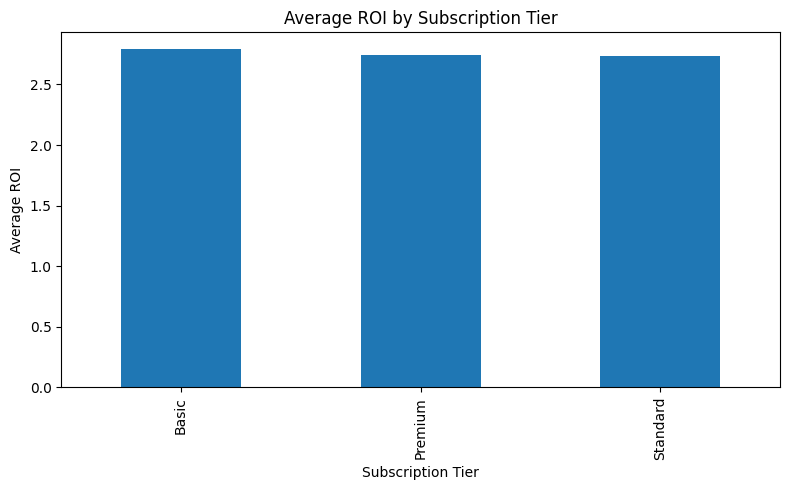

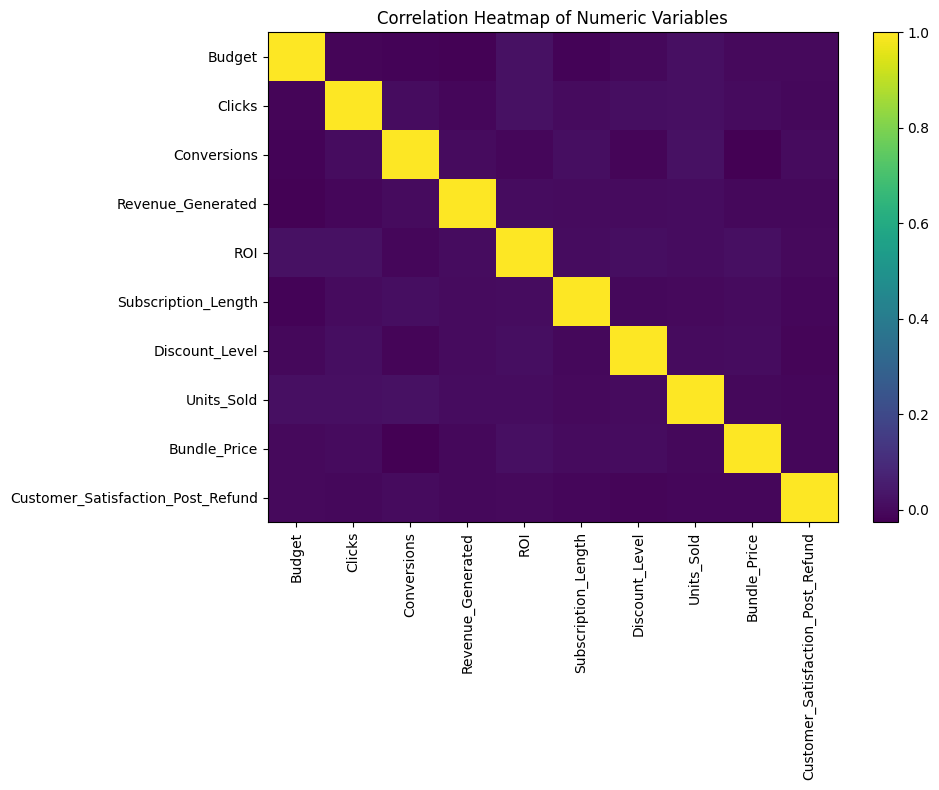

In [6]:
# ROI Distribution
plt.figure(figsize=(8,5))
plt.hist(df[target], bins=30)
plt.title("Distribution of ROI")
plt.xlabel("ROI")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/roi_distribution.png")
plt.show()

# Revenue vs Budget
plt.figure(figsize=(8,5))
plt.scatter(df["Budget"], df["Revenue_Generated"], alpha=0.5)
plt.title("Budget vs Revenue Generated")
plt.xlabel("Budget")
plt.ylabel("Revenue Generated")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/budget_vs_revenue.png")
plt.show()

# Budget vs ROI
plt.figure(figsize=(8,5))
plt.scatter(df["Budget"], df["ROI"], alpha=0.5)
plt.title("Budget vs ROI")
plt.xlabel("Budget")
plt.ylabel("ROI")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/budget_vs_roi.png")
plt.show()

# Discount Level vs ROI
if "Discount_Level" in df.columns:
    plt.figure(figsize=(8,5))
    df.groupby("Discount_Level")["ROI"].mean().plot(kind="bar")
    plt.title("Average ROI by Discount Level")
    plt.xlabel("Discount Level")
    plt.ylabel("Average ROI")
    plt.tight_layout()
    plt.savefig("/kaggle/working/figures/roi_by_discount_level.png")
    plt.show()

# Subscription Tier vs ROI
if "Subscription_Tier" in df.columns:
    plt.figure(figsize=(8,5))
    df.groupby("Subscription_Tier")["ROI"].mean().plot(kind="bar")
    plt.title("Average ROI by Subscription Tier")
    plt.xlabel("Subscription Tier")
    plt.ylabel("Average ROI")
    plt.tight_layout()
    plt.savefig("/kaggle/working/figures/roi_by_subscription_tier.png")
    plt.show()

# Correlation Heatmap without seaborn
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/correlation_heatmap.png")
plt.show()

corr.to_csv("/kaggle/working/tables/correlation_matrix.csv")

In [7]:
# Drop ID-like columns because they are identifiers, not useful predictors
drop_cols = []
for col in df.columns:
    if "ID" in col or "Id" in col or "id" in col:
        drop_cols.append(col)

drop_cols = list(set(drop_cols))
print("Dropped ID columns:", drop_cols)

data = df.drop(columns=drop_cols)

# Remove target from features
X = data.drop(columns=[target])
y = data[target]

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Features:", numeric_features)
print("Categorical Features:", categorical_features)

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Dropped ID columns: ['Flash_Sale_ID', 'Customer_ID', 'Campaign_ID', 'Bundle_ID', 'Product_ID']
Numerical Features: ['Budget', 'Clicks', 'Conversions', 'Revenue_Generated', 'Subscription_Length', 'Discount_Level', 'Units_Sold', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund']
Categorical Features: ['Subscription_Tier', 'Common_Keywords']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 8000
Testing rows: 2000


In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100, random_state=42
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

results = []

trained_models = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    
    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    })
    
    trained_models[name] = pipeline
    
results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)

print("\nModel Comparison Results:")
display(results_df)

results_df.to_csv("/kaggle/working/tables/model_comparison_results.csv", index=False)


Model Comparison Results:


,Model,R2 Score,MAE,MSE,RMSE
0,Linear Regression,-0.000871,1.123304,1.694725,1.301816
3,Gradient Boosting Regressor,-0.009468,1.128463,1.709283,1.307396
2,Random Forest Regressor,-0.018894,1.130669,1.725244,1.313485
1,Decision Tree Regressor,-1.043869,1.519670,3.460783,1.860318


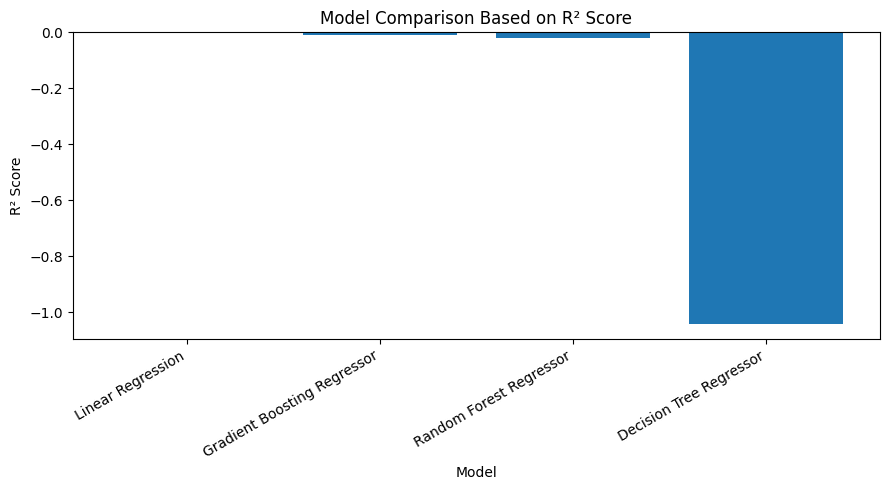

In [10]:
plt.figure(figsize=(9,5))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.title("Model Comparison Based on R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/model_comparison_r2.png")
plt.show()

Best Model: Linear Regression


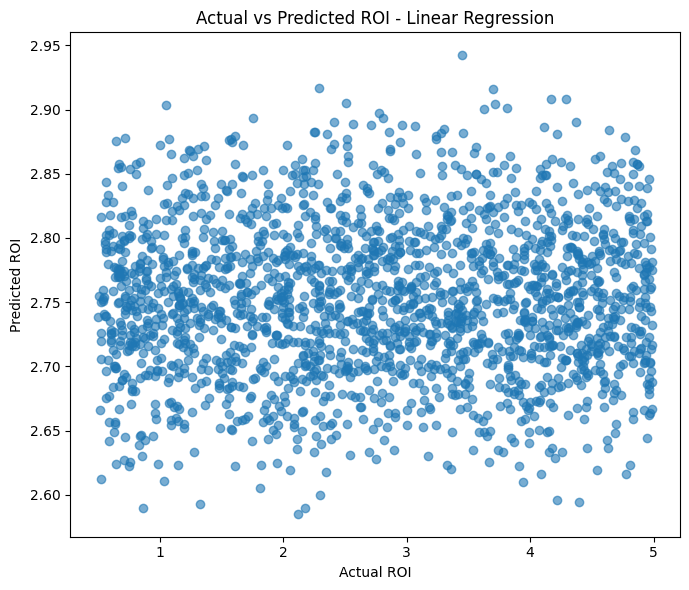

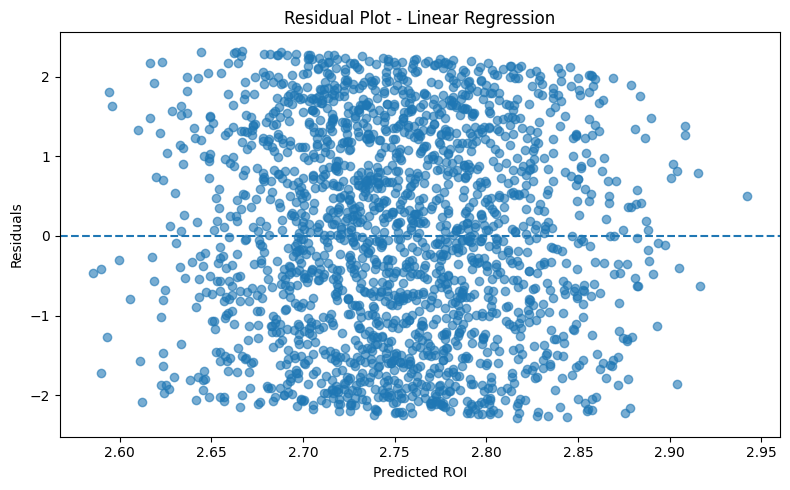

In [11]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

best_preds = best_model.predict(X_test)

# Actual vs Predicted
plt.figure(figsize=(7,6))
plt.scatter(y_test, best_preds, alpha=0.6)
plt.title(f"Actual vs Predicted ROI - {best_model_name}")
plt.xlabel("Actual ROI")
plt.ylabel("Predicted ROI")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/actual_vs_predicted_roi.png")
plt.show()

# Residual Plot
residuals = y_test - best_preds

plt.figure(figsize=(8,5))
plt.scatter(best_preds, residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")
plt.title(f"Residual Plot - {best_model_name}")
plt.xlabel("Predicted ROI")
plt.ylabel("Residuals")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/residual_plot.png")
plt.show()

In [12]:
final_model = best_model.named_steps["model"]

try:
    feature_names_num = numeric_features
    feature_names_cat = list(
        best_model.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .get_feature_names_out(categorical_features)
    )
    feature_names = feature_names_num + feature_names_cat
    
    if hasattr(final_model, "feature_importances_"):
        importances = final_model.feature_importances_
        
        feature_importance_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        }).sort_values(by="Importance", ascending=False).head(15)
        
        display(feature_importance_df)
        feature_importance_df.to_csv(
            "/kaggle/working/tables/feature_importance.csv",
            index=False
        )
        
        plt.figure(figsize=(10,6))
        plt.barh(
            feature_importance_df["Feature"],
            feature_importance_df["Importance"]
        )
        plt.gca().invert_yaxis()
        plt.title(f"Top 15 Feature Importance - {best_model_name}")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.savefig("/kaggle/working/figures/feature_importance.png")
        plt.show()
    else:
        print("Feature importance is not available for this model.")
except Exception as e:
    print("Feature importance could not be generated:", e)

Feature importance is not available for this model.


In [13]:
research_questions = pd.DataFrame({
    "Research Question": [
        "RQ1: Which variables most influence ROI?",
        "RQ2: Which regression model predicts ROI most accurately?",
        "RQ3: How does marketing budget affect ROI?",
        "RQ4: How do discounts affect revenue and ROI?",
        "RQ5: Does customer subscription tier influence ROI?",
        "RQ6: Can customer satisfaction help predict ROI?",
        "RQ7: Which model provides the best balance of accuracy and interpretability?"
    ],
    "Answer Summary": [
        "Feature importance and correlation analysis identify the most influential predictors.",
        f"The best-performing model based on R² score is {best_model_name}.",
        "Scatter plots between Budget, Revenue Generated, and ROI show the relationship.",
        "Grouped bar charts compare average ROI across discount levels.",
        "Grouped analysis compares average ROI across subscription tiers.",
        "Customer satisfaction is included as a predictive feature in the regression models.",
        "Model comparison using R², MAE, MSE, and RMSE supports final model selection."
    ]
})

display(research_questions)
research_questions.to_csv("/kaggle/working/tables/research_questions_summary.csv", index=False)

,Research Question,Answer Summary
0,RQ1: Which variables most influence ROI?,Feature importance and correlation analysis id...
1,RQ2: Which regression model predicts ROI most ...,The best-performing model based on R² score is...
2,RQ3: How does marketing budget affect ROI?,"Scatter plots between Budget, Revenue Generate..."
3,RQ4: How do discounts affect revenue and ROI?,Grouped bar charts compare average ROI across ...
4,RQ5: Does customer subscription tier influence...,Grouped analysis compares average ROI across s...
5,RQ6: Can customer satisfaction help predict ROI?,Customer satisfaction is included as a predict...
6,RQ7: Which model provides the best balance of ...,"Model comparison using R², MAE, MSE, and RMSE ..."


In [14]:
print("\nFINAL CONCLUSION")
print("This supervised learning project successfully used the Marketing and Product Performance Dataset to predict ROI.")
print("Multiple regression models were trained and evaluated.")
print(f"The best model was: {best_model_name}")
print("The project generated figures, tables, and evaluation results suitable for the assignment submission.")

print("\nSaved Files:")
print("Figures saved in: /kaggle/working/figures")
print("Tables saved in: /kaggle/working/tables")


FINAL CONCLUSION
This supervised learning project successfully used the Marketing and Product Performance Dataset to predict ROI.
Multiple regression models were trained and evaluated.
The best model was: Linear Regression
The project generated figures, tables, and evaluation results suitable for the assignment submission.

Saved Files:
Figures saved in: /kaggle/working/figures
Tables saved in: /kaggle/working/tables
